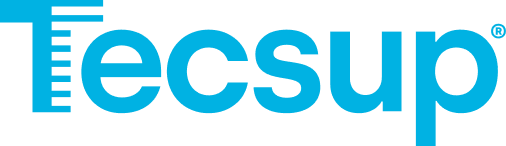

**DEPARTAMENTO DE TECNOLOGÍA DIGITAL Y GESTIÓN**

**Carrera de Big Data y Ciencia de Datos**

# Laboratorio 16 - DESARROLLO DE APLICACIONES DE MACHINE LEARNING 

**Integrantes**
- Olortegui Perez, Kevin Estiben

In [1]:
# %pip install ucimlrepo pandas numpy matplotlib seaborn scikit-learn imbalanced-learn feature_engine -q

In [2]:
import pandas as pd
import numpy as np
from ucimlrepo import fetch_ucirepo

# Cargar el conjunto de datos
adult = fetch_ucirepo(id=2)

# Extraer características y etiquetas
X = adult.data.features
y = adult.data.targets

# Unir características y etiquetas en un solo DataFrame
df = pd.concat([X, y], axis=1)

# Renombrar la columna de la variable objetivo
df.rename(columns={'income': 'target'}, inplace=True)

print("Dimensiones del DataFrame combinado:")
print(df.shape)
print("\nPrimeras 5 filas del DataFrame:")
print(df.head())

Dimensiones del DataFrame combinado:
(48842, 15)

Primeras 5 filas del DataFrame:
   age         workclass  fnlwgt  education  education-num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital-status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital-gain  capital-loss  hours-per-week native-country target  
0          2174             0 

In [3]:
# Reemplazar '?' con NaN
df.replace('?', np.nan, inplace=True)

# Imputar valores faltantes con la moda
for col in ['workclass', 'occupation', 'native-country']:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("Cantidad de valores nulos después de la imputación:")
print(df.isnull().sum())

# Limpiar las categorías de la variable objetivo
df['target'] = df['target'].str.replace('.', '', regex=False).str.strip()

Cantidad de valores nulos después de la imputación:
age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
target            0
dtype: int64


C:\Users\Alumno\AppData\Local\Temp\ipykernel_2504\3339046693.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [4]:
# Tratamiento de outliers a nivel univariado usando el método IQR
for col in df.select_dtypes(include=np.number).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = np.clip(df[col], lower_bound, upper_bound)

print("\nDescripción de las variables numéricas después del tratamiento de outliers:")
print(df.describe())


Descripción de las variables numéricas después del tratamiento de outliers:
                age         fnlwgt  education-num  capital-gain  capital-loss  \
count  48842.000000   48842.000000   48842.000000       48842.0       48842.0   
mean      38.618566  186770.707163      10.122088           0.0           0.0   
std       13.630359   95328.614282       2.456895           0.0           0.0   
min       17.000000   12285.000000       4.500000           0.0           0.0   
25%       28.000000  117550.500000       9.000000           0.0           0.0   
50%       37.000000  178144.500000      10.000000           0.0           0.0   
75%       48.000000  237642.000000      12.000000           0.0           0.0   
max       78.000000  417779.250000      16.000000           0.0           0.0   

       hours-per-week  
count    48842.000000  
mean        41.192805  
std          6.184799  
min         32.500000  
25%         40.000000  
50%         40.000000  
75%         45.000000  
m

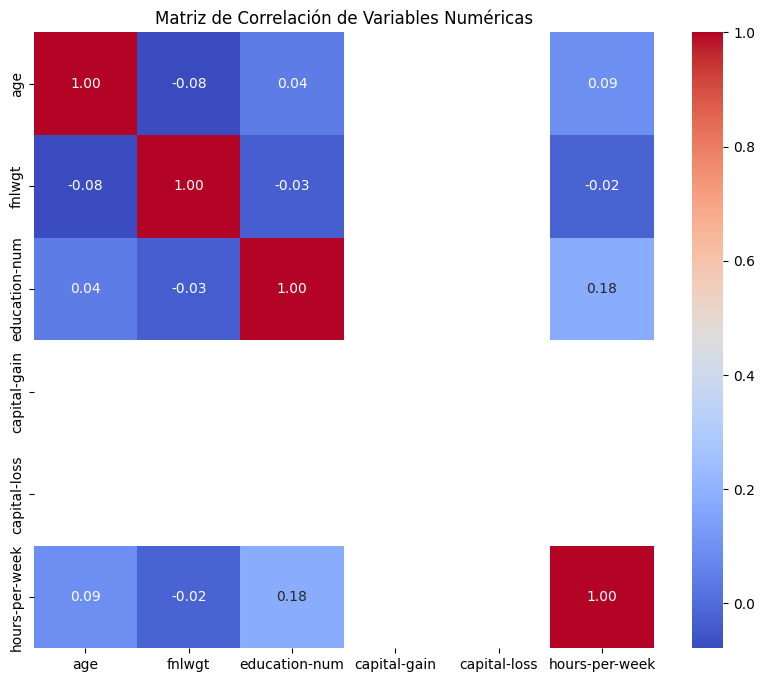

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Matriz de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

In [6]:
# Función para calcular el IV
def calculate_iv(df, feature, target):
    lst = []
    for i in range(df[feature].nunique()):
        val = list(df[feature].unique())[i]
        lst.append([feature, val, df[df[feature] == val].count()[feature], df[(df[feature] == val) & (df[target] == '>50K')].count()[feature]])
    data = pd.DataFrame(lst, columns=['Variable', 'Value', 'All', 'Good'])
    data = data[data['All'] > 0]
    data['Share'] = data['All'] / data['All'].sum()
    data['Bad'] = data['All'] - data['Good']
    data['Distr_Good'] = data['Good'] / data['Good'].sum()
    data['Distr_Bad'] = data['Bad'] / data['Bad'].sum()
    # Prevenir división por cero
    data['Distr_Good'] = data['Distr_Good'].replace(0, 0.0001)
    data['Distr_Bad'] = data['Distr_Bad'].replace(0, 0.0001)
    data['WoE'] = np.log(data['Distr_Good'] / data['Distr_Bad'])
    data['IV'] = (data['Distr_Good'] - data['Distr_Bad']) * data['WoE']
    data['IV'] = data['IV'].sum()
    return data['IV'].values[0]

# Calcular IV para variables categóricas
iv_scores = {}
categorical_cols = df.select_dtypes(include=['object']).drop('target', axis=1).columns
for col in categorical_cols:
    iv_scores[col] = calculate_iv(df, col, 'target')

iv_df = pd.DataFrame.from_dict(iv_scores, orient='index', columns=['IV']).sort_values(by='IV', ascending=False)
print("Information Value (IV) de las variables categóricas:")
print(iv_df)

# Seleccionar variables con IV > 0.1 (predictores medios y fuertes)
best_features = iv_df[iv_df['IV'] > 0.1].index.tolist()
print(f"\nMejores variables categóricas seleccionadas: {best_features}")

Information Value (IV) de las variables categóricas:
                      IV
relationship    1.527717
marital-status  1.348677
education       0.736905
occupation      0.625795
sex             0.300521
workclass       0.133048
native-country  0.075048
race            0.067842

Mejores variables categóricas seleccionadas: ['relationship', 'marital-status', 'education', 'occupation', 'sex', 'workclass']


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Combinar mejores variables categóricas con las numéricas
final_features = best_features + df.select_dtypes(include=np.number).columns.tolist()
X_final = df[final_features]
y_final = df['target'].apply(lambda x: 1 if x == '>50K' else 0)

# Convertir variables categóricas a dummies
X_final = pd.get_dummies(X_final, columns=best_features, drop_first=True)

# Escalar variables numéricas
scaler = StandardScaler()
numerical_cols = df.select_dtypes(include=np.number).columns
X_final[numerical_cols] = scaler.fit_transform(X_final[numerical_cols])

# Separar datos en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.2, random_state=42, stratify=y_final)

# Balanceo de clases con SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("\nDimensiones de los datos de entrenamiento (después de SMOTE):", X_train_res.shape)
print("Distribución de clases en entrenamiento (después de SMOTE):\n", y_train_res.value_counts())


Dimensiones de los datos de entrenamiento (después de SMOTE): (59448, 53)
Distribución de clases en entrenamiento (después de SMOTE):
 target
0    29724
1    29724
Name: count, dtype: int64


In [8]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score

# Definir los modelos
models = {
    'k-NN': KNeighborsClassifier(),
    'SVM': SVC(probability=True),
    'Regresión Logística': LogisticRegression(),
    'Árbol de Clasificación': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier()
}

# Definir los hiperparámetros para la búsqueda
param_grids = {
    'k-NN': {'n_neighbors': [3, 5, 7, 9]},
    'SVM': {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto']},
    'Regresión Logística': {'C': [0.1, 1, 10], 'solver': ['liblinear']},
    'Árbol de Clasificación': {'max_depth': [None, 10, 20, 30], 'min_samples_leaf': [1, 2, 4]},
    'Random Forest': {'n_estimators': [50, 100, 200], 'max_depth': [10, 20, None]}
}

results = {}

# Entrenar y evaluar cada modelo
for name, model in models.items():
    print(f"--- Entrenando {name} ---")

    # Búsqueda en Cuadrícula (Grid Search)
    grid_search = GridSearchCV(model, param_grids[name], cv=3, scoring='accuracy', n_jobs=-1)
    grid_search.fit(X_train_res, y_train_res)
    grid_accuracy = grid_search.best_score_

    # Búsqueda Aleatoria (Random Search)
    random_search = RandomizedSearchCV(model, param_grids[name], n_iter=4, cv=3, scoring='accuracy', n_jobs=-1, random_state=42)
    random_search.fit(X_train_res, y_train_res)
    random_accuracy = random_search.best_score_

    # Seleccionar el mejor resultado y entrenar el modelo final
    if grid_accuracy > random_accuracy:
        best_params = grid_search.best_params_
        final_model = grid_search.best_estimator_
    else:
        best_params = random_search.best_params_
        final_model = random_search.best_estimator_

    # Evaluar en el conjunto de prueba
    y_pred = final_model.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_pred)

    results[name] = {
        'Mejores Hiperparámetros': best_params,
        'Accuracy en Prueba': test_accuracy
    }

# Encontrar el mejor modelo global
best_model_name = max(results, key=lambda name: results[name]['Accuracy en Prueba'])
best_model_info = results[best_model_name]

print("\n--- Resultados Finales ---")
for name, result in results.items():
    print(f"\nModelo: {name}")
    print(f"  Accuracy en Prueba: {result['Accuracy en Prueba']:.4f}")
    print(f"  Mejores Hiperparámetros: {result['Mejores Hiperparámetros']}")

print("\n==============================================")
print(f"🏆 Mejor Modelo: {best_model_name}")
print(f"  🎯 Mejor Accuracy en Prueba: {best_model_info['Accuracy en Prueba']:.4f}")
print(f"  ⚙️ Hiperparámetros Óptimos: {best_model_info['Mejores Hiperparámetros']}")
print("==============================================")

--- Entrenando k-NN ---
--- Entrenando SVM ---
--- Entrenando Regresión Logística ---


c:\Users\Alumno\Desktop\olortegui_lab16\.venv\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 3 is smaller than n_iter=4. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


--- Entrenando Árbol de Clasificación ---
--- Entrenando Random Forest ---

--- Resultados Finales ---

Modelo: k-NN
  Accuracy en Prueba: 0.7810
  Mejores Hiperparámetros: {'n_neighbors': 3}

Modelo: SVM
  Accuracy en Prueba: 0.7978
  Mejores Hiperparámetros: {'C': 10, 'gamma': 'scale'}

Modelo: Regresión Logística
  Accuracy en Prueba: 0.7872
  Mejores Hiperparámetros: {'solver': 'liblinear', 'C': 10}

Modelo: Árbol de Clasificación
  Accuracy en Prueba: 0.7844
  Mejores Hiperparámetros: {'max_depth': 20, 'min_samples_leaf': 1}

Modelo: Random Forest
  Accuracy en Prueba: 0.8148
  Mejores Hiperparámetros: {'max_depth': None, 'n_estimators': 200}

🏆 Mejor Modelo: Random Forest
  🎯 Mejor Accuracy en Prueba: 0.8148
  ⚙️ Hiperparámetros Óptimos: {'max_depth': None, 'n_estimators': 200}
